In [1]:
import os
import joblib
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Create the models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

c:\Users\krish\Documents\SEM_4\ML_ENDSEM_PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


# Update the extension to .xlsx
file_path = 'data/mymoviedb.xlsx'
print(f"Loading data from {file_path}...")

# Use read_excel instead of read_csv
df = pd.read_excel(file_path)
df = df.drop_duplicates(subset=['Title'], keep='first')
# Ensure no NaN values in the Overview column
df['Overview'] = df['Overview'].fillna('').astype(str)
df.head(3)

Loading data from data/mymoviedb.xlsx...


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15 00:00:00,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01 00:00:00,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25 00:00:00,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...


In [3]:
print("Loading Sentence Transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings... (this may take a moment)")
embeddings = model.encode(df['Overview'].tolist(), show_progress_bar=True)

df['Overview_Embedding'] = embeddings.tolist()
print("Embeddings generated and added to dataframe.")

Loading Sentence Transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14485.42it/s]


Generating embeddings... (this may take a moment)


Batches: 100%|██████████| 298/298 [00:36<00:00,  8.12it/s]

Embeddings generated and added to dataframe.


Calculating inertias...


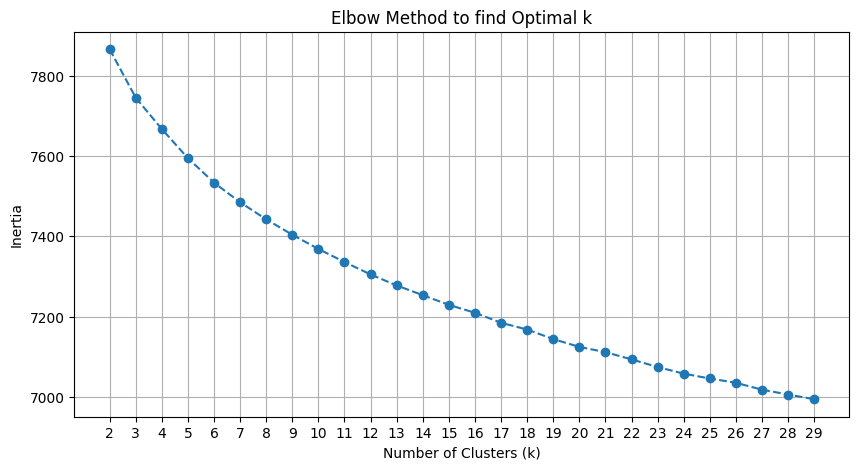

In [41]:
inertias = []
K_range = range(2, 30) 

print("Calculating inertias...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [42]:
# Set this to the optimal number you determined from the elbow curve above
OPTIMAL_K = 30

print(f"Training final K-Means model with K={OPTIMAL_K}...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

# Fit and predict
df['Cluster'] = kmeans_final.fit_predict(embeddings)

# Save the trained model to the models directory
model_path = 'models/kmeans_movie_model.joblib'
joblib.dump(kmeans_final, model_path)
print(f"Model successfully saved to {model_path}")

Training final K-Means model with K=30...
Model successfully saved to models/kmeans_movie_model.joblib


Reducing dimensions using PCA for visualization...


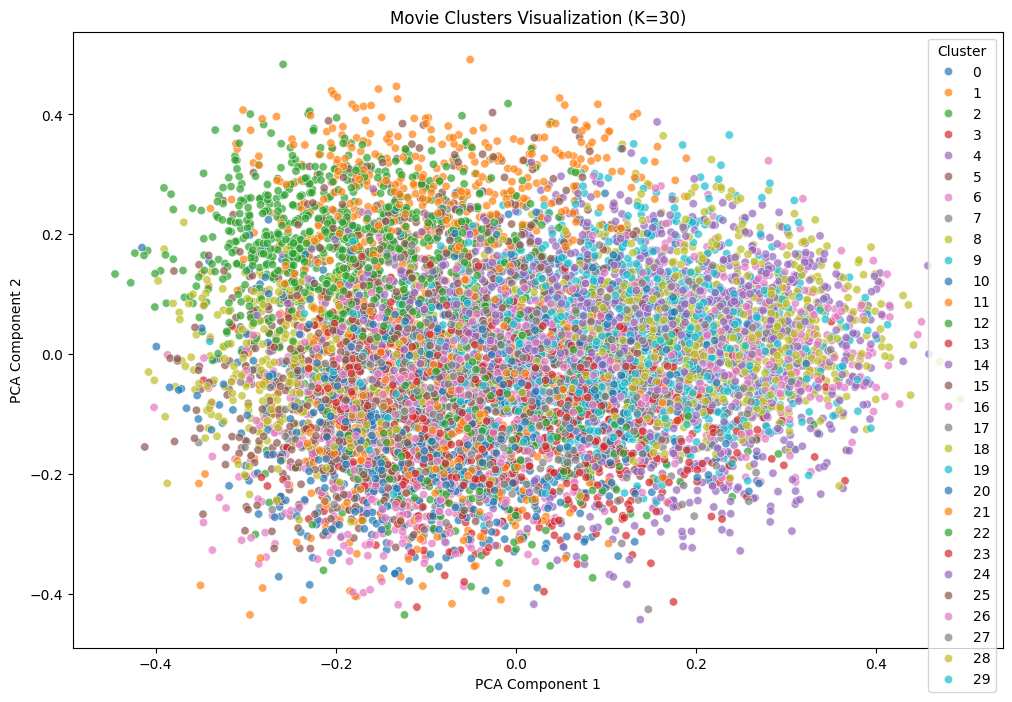

In [43]:
print("Reducing dimensions using PCA for visualization...")
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=reduced_embeddings[:, 0], 
    y=reduced_embeddings[:, 1], 
    hue=df['Cluster'], 
    palette='tab10', 
    alpha=0.7, 
    legend='full'
)
plt.title(f'Movie Clusters Visualization (K={OPTIMAL_K})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [44]:
for cluster_num in sorted(df['Cluster'].unique()):
    print(f"\n[ Cluster {cluster_num} ]")
    cluster_movies = df[df['Cluster'] == cluster_num]
    
    sample_movies = cluster_movies.head(5)
    
    for _, row in sample_movies.iterrows():
        print(f"  - {row['Title']} | Genres: {row['Genre']}")
        
    print(f"  ... (Total movies in this cluster: {len(cluster_movies)})")


[ Cluster 0 ]
  - Shang-Chi and the Legend of the Ten Rings | Genres: Action, Adventure, Fantasy
  - Dynasty Warriors | Genres: Action, Adventure, Fantasy
  - Mulan | Genres: Adventure, Fantasy, Drama
  - Train to Busan | Genres: Action, Horror, Thriller
  - The Karate Kid | Genres: Action, Adventure, Drama, Family
  ... (Total movies in this cluster: 189)

[ Cluster 1 ]
  - Pursuit | Genres: Action, Crime, Thriller
  - Restless | Genres: Action, Thriller, Crime
  - The Hunting | Genres: Horror
  - Brazen | Genres: Thriller, Mystery, Drama
  - Ripper Untold | Genres: Horror
  ... (Total movies in this cluster: 391)

[ Cluster 2 ]
  - American Siege | Genres: Action, Thriller, Crime, Drama
  - Blacklight | Genres: Action, Thriller
  - Dangerous | Genres: Action, Thriller
  - Survive the Game | Genres: Action, Thriller, Crime
  - Apex | Genres: Action, Thriller, Science Fiction
  ... (Total movies in this cluster: 456)

[ Cluster 3 ]
  - Mortal Kombat | Genres: Action, Fantasy, Adventur

In [45]:


# 1. Create a copy of just the columns we need so we don't alter your main df
genre_df = df[['Cluster', 'Genre']].copy()

# 2. Drop any rows where the Genre might be NaN/missing
genre_df = genre_df.dropna(subset=['Genre'])

# 3. Split the comma-separated strings into Python lists
genre_df['Genre'] = genre_df['Genre'].astype(str).str.split(',')

# 4. Use explode() to create a new row for every single genre in the list
genre_exploded = genre_df.explode('Genre')

# 5. Strip any accidental leading/trailing whitespace (e.g., " Action" -> "Action")
genre_exploded['Genre'] = genre_exploded['Genre'].str.strip()

# 6. Loop through and print the value counts!
print("="*40)
print("TOP GENRES PER CLUSTER")
print("="*40)

for cluster_num in sorted(genre_exploded['Cluster'].unique()):
    print(f"\n[ Cluster {cluster_num} ]")
    
    # Filter down to just the current cluster
    cluster_data = genre_exploded[genre_exploded['Cluster'] == cluster_num]
    
    # Get the counts of each genre
    genre_counts = cluster_data['Genre'].value_counts()
    
    # Print the top 5 most common genres for this cluster
    # (Change .head(5) if you want to see more or fewer)
    for genre, count in genre_counts.head(5).items():
        print(f"  - {genre}: {count}")

TOP GENRES PER CLUSTER

[ Cluster 0 ]
  - Action: 153
  - Drama: 83
  - Adventure: 48
  - Thriller: 42
  - Comedy: 41

[ Cluster 1 ]
  - Thriller: 282
  - Crime: 193
  - Drama: 149
  - Action: 144
  - Mystery: 116

[ Cluster 2 ]
  - Action: 266
  - Crime: 238
  - Thriller: 204
  - Drama: 184
  - Comedy: 108

[ Cluster 3 ]
  - Drama: 133
  - Comedy: 108
  - Action: 63
  - Family: 50
  - Adventure: 36

[ Cluster 4 ]
  - Family: 158
  - Fantasy: 140
  - Animation: 129
  - Adventure: 86
  - Comedy: 79

[ Cluster 5 ]
  - Action: 177
  - Science Fiction: 125
  - Adventure: 106
  - Animation: 92
  - Comedy: 54

[ Cluster 6 ]
  - Animation: 179
  - Action: 152
  - Adventure: 120
  - Science Fiction: 90
  - Comedy: 81

[ Cluster 7 ]
  - Drama: 129
  - Comedy: 82
  - Crime: 42
  - Thriller: 42
  - Romance: 41

[ Cluster 8 ]
  - Drama: 258
  - Romance: 175
  - Comedy: 97
  - Thriller: 46
  - Crime: 28

[ Cluster 9 ]
  - Comedy: 182
  - Drama: 144
  - Romance: 79
  - Horror: 59
  - Thriller: 57

[

In [49]:
import os
import shutil
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

# 1. Clean the dataframe to remove duplicate movies before processing
print("Removing duplicates from the dataset...")
df = df.drop_duplicates(subset=['Title'], keep='first')

print("Setting up LangChain HuggingFace Embeddings...")
hf_embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

print("Preparing documents for ChromaDB...")
docs = []
ids = [] # Keeping track of IDs ensures Chroma updates instead of appends
for idx, row in df.iterrows():
    doc = Document(
        page_content=str(row['Overview']),
        metadata={
            "title": str(row['Title']),
            "genre": str(row['Genre']),
            "cluster": int(row['Cluster']) 
        }
    )
    docs.append(doc)
    ids.append(str(idx)) # Use the dataframe index as the unique ID

# 2. Completely clear the old database folder to prevent stacking old runs
db_path = './final_chroma_db'
if os.path.exists(db_path):
    print("Clearing old ChromaDB data...")
    shutil.rmtree(db_path)
    
os.makedirs(db_path, exist_ok=True)

print("Ingesting data into Chroma Vector Store (this may take a minute)...")
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=hf_embeddings,
    ids=ids, # Passing explicit IDs prevents future duplication
    persist_directory=db_path
)
print("ChromaDB successfully created and persisted without duplicates!")

Removing duplicates from the dataset...
Setting up LangChain HuggingFace Embeddings...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11424.09it/s]


Preparing documents for ChromaDB...
Ingesting data into Chroma Vector Store (this may take a minute)...
ChromaDB successfully created and persisted without duplicates!


In [31]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

print("Training Agglomerative Clustering with exactly 10 clusters...")

# 1. Force the model to make exactly 10 clusters
TARGET_K = 10
hc_model_10 = AgglomerativeClustering(
    n_clusters=TARGET_K, 
    distance_threshold=None, # We MUST set this to None when specifying n_clusters
    metric='euclidean', 
    linkage='ward'
)

# Fit the model and save the labels to a new column
df['Cluster_10'] = hc_model_10.fit_predict(embeddings)
print(f"Successfully created {TARGET_K} clusters!\n")

# ==========================================
# 2. Analyze the Genres in Each Cluster
# ==========================================
print("==========================================")
print("GENRE DISTRIBUTION PER CLUSTER (Top 5)")
print("==========================================")

# Create a clean dataframe for genre analysis
genre_df = df[['Cluster_10', 'Genre']].copy().dropna(subset=['Genre'])

# Split the comma-separated genres and explode them into individual rows
genre_df['Genre'] = genre_df['Genre'].astype(str).str.split(',')
genre_exploded = genre_df.explode('Genre')
genre_exploded['Genre'] = genre_exploded['Genre'].str.strip() # Clean up white spaces

# Loop through all 10 clusters and print what genres they contain
for cluster_num in sorted(genre_exploded['Cluster_10'].unique()):
    print(f"\n[ Cluster {cluster_num} ]")
    
    # Filter to just the current cluster
    cluster_data = genre_exploded[genre_exploded['Cluster_10'] == cluster_num]
    
    # Get the counts of each genre in this cluster
    genre_counts = cluster_data['Genre'].value_counts()
    
    # Calculate total genres listed in this cluster to show percentages (optional but helpful)
    total_in_cluster = len(cluster_data)
    
    # Print the top 5 most common genres for this cluster
    for genre, count in genre_counts.head(5).items():
        percentage = (count / total_in_cluster) * 100
        print(f"  - {genre}: {count} ({percentage:.1f}%)")

Training Agglomerative Clustering with exactly 10 clusters...
Successfully created 10 clusters!

GENRE DISTRIBUTION PER CLUSTER (Top 5)

[ Cluster 0 ]
  - Comedy: 447 (23.3%)
  - Drama: 430 (22.4%)
  - Romance: 371 (19.4%)
  - Thriller: 125 (6.5%)
  - Horror: 94 (4.9%)

[ Cluster 1 ]
  - Drama: 1087 (18.3%)
  - Comedy: 979 (16.4%)
  - Thriller: 470 (7.9%)
  - Romance: 424 (7.1%)
  - Action: 402 (6.7%)

[ Cluster 2 ]
  - Science Fiction: 322 (19.8%)
  - Action: 222 (13.7%)
  - Adventure: 186 (11.5%)
  - Thriller: 163 (10.0%)
  - Drama: 129 (7.9%)

[ Cluster 3 ]
  - Drama: 559 (21.3%)
  - Thriller: 362 (13.8%)
  - Comedy: 297 (11.3%)
  - Horror: 258 (9.8%)
  - Romance: 246 (9.4%)

[ Cluster 4 ]
  - Action: 533 (20.2%)
  - Animation: 324 (12.3%)
  - Drama: 295 (11.2%)
  - Adventure: 251 (9.5%)
  - Science Fiction: 210 (8.0%)

[ Cluster 5 ]
  - Horror: 390 (20.4%)
  - Thriller: 257 (13.4%)
  - Drama: 186 (9.7%)
  - Comedy: 164 (8.6%)
  - Action: 148 (7.7%)

[ Cluster 6 ]
  - Family: 385 (1

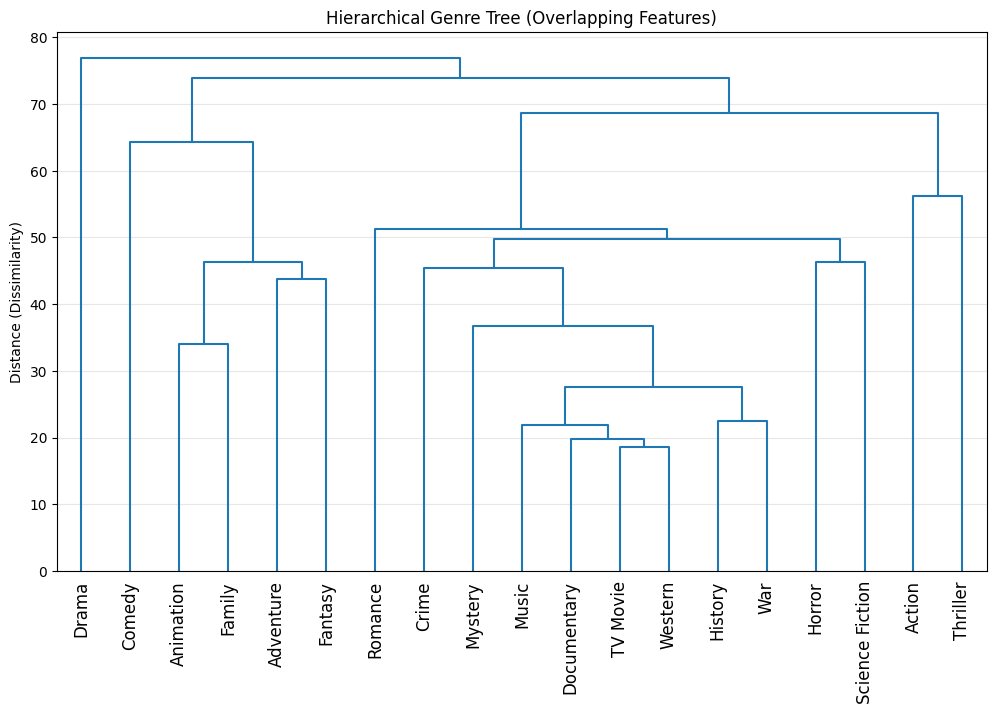

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Parse the strings into lists
# We split by comma and strip whitespace to ensure ' Action' and 'Action' match
genre_lists = df['Genre'].fillna('').apply(lambda x: [g.strip() for g in str(x).split(',') if g.strip()])

# 2. One-Hot Encode (Multi-Label Binarization)
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_lists)
genre_names = mlb.classes_

# 3. Generate the Linkage Matrix (Ward's Method minimizes variance)
# We cluster the genres (the .T) to see which genres are "family members"
linkage_matrix = sch.linkage(genre_matrix.T, method='ward')

# 4. Visualization: The Dendrogram
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(
    linkage_matrix, 
    labels=genre_names, 
    leaf_rotation=90,
    color_threshold=10 # Adjust this to change how clusters are colored
)
plt.title('Hierarchical Genre Tree (Overlapping Features)')
plt.ylabel('Distance (Dissimilarity)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 5. Fit the actual Hierarchical Model
# Let's assume we want 10 macro-genre groups
hierarchical_cluster = AgglomerativeClustering(n_clusters=10, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical_cluster.fit_predict(genre_matrix)

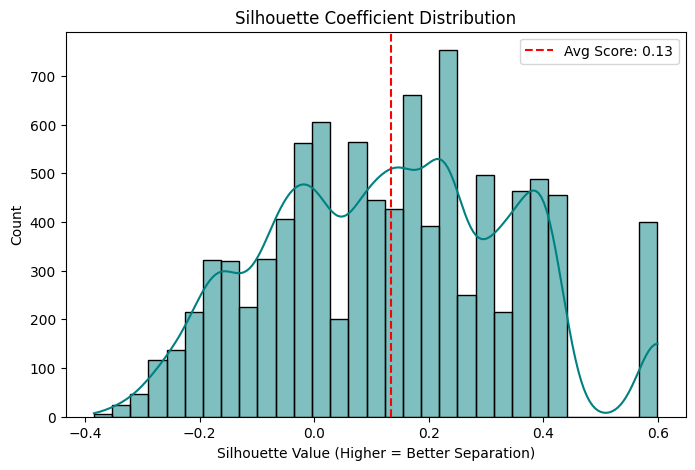

In [16]:
from sklearn.metrics import silhouette_samples, silhouette_score

# Calculate average score
avg_sil = silhouette_score(genre_matrix, df['Hierarchical_Cluster'])

# Calculate per-sample scores
sample_values = silhouette_samples(genre_matrix, df['Hierarchical_Cluster'])

plt.figure(figsize=(8, 5))
sns.histplot(sample_values, kde=True, color='teal')
plt.axvline(avg_sil, color='red', linestyle='--', label=f'Avg Score: {avg_sil:.2f}')
plt.title('Silhouette Coefficient Distribution')
plt.xlabel('Silhouette Value (Higher = Better Separation)')
plt.legend()
plt.show()

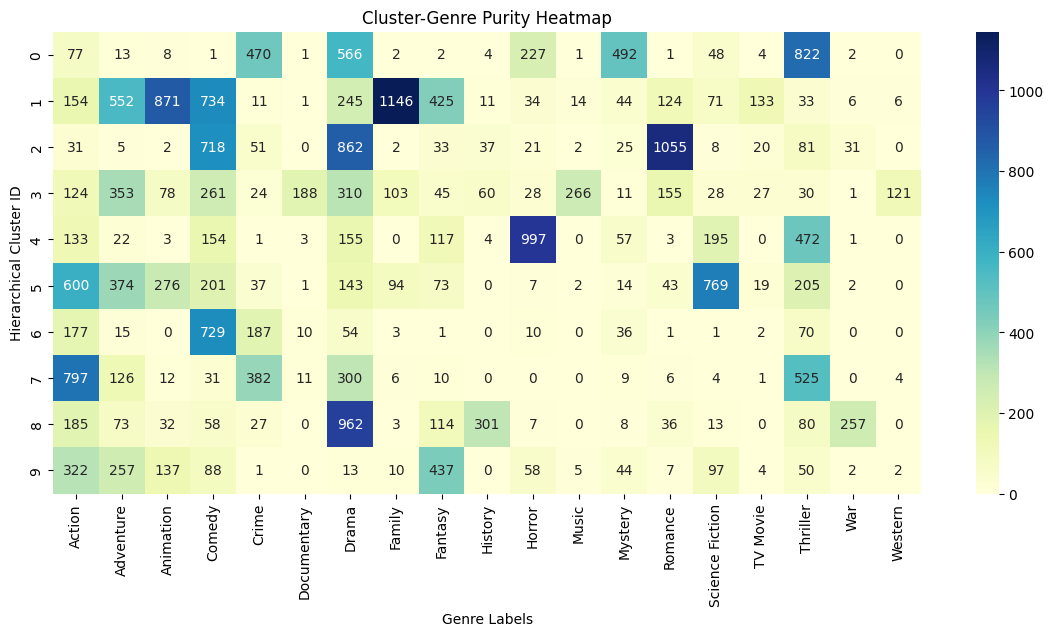

In [17]:
# Create a cross-tabulation of Clusters vs Genres
cluster_genre_dist = []
for i in range(10): # for each hierarchical cluster
    subset = genre_matrix[df['Hierarchical_Cluster'] == i]
    genre_sums = subset.sum(axis=0)
    cluster_genre_dist.append(genre_sums)

purity_df = pd.DataFrame(cluster_genre_dist, columns=genre_names)

plt.figure(figsize=(14, 6))
sns.heatmap(purity_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cluster-Genre Purity Heatmap')
plt.xlabel('Genre Labels')
plt.ylabel('Hierarchical Cluster ID')
plt.show()

In [18]:
# 1. Get the Top 5 movies for each hierarchical cluster
print("="*60)
print("HIERARCHICAL CLUSTER COMPONENT SAMPLES")
print("="*60)

for i in range(10):
    print(f"\n[ Cluster {i} ]")
    
    # Get movie titles in this cluster
    titles = df[df['Hierarchical_Cluster'] == i]['Title'].head(5).tolist()
    print(f"Sample Movies: {', '.join(titles)}")
    
    # Get genre counts for this cluster
    # We use the exploded version if you created it earlier, or compute it here:
    cluster_genres = df[df['Hierarchical_Cluster'] == i]['Genre'].str.split(',').explode().str.strip()
    top_genres = cluster_genres.value_counts().head(3)
    
    print("Primary Genres:")
    for genre, count in top_genres.items():
        print(f"  - {genre}: {count}")

HIERARCHICAL CLUSTER COMPONENT SAMPLES

[ Cluster 0 ]
Sample Movies: The Batman, No Exit, Scream, Kimi, Nightmare Alley
Primary Genres:
  - Thriller: 822
  - Drama: 566
  - Mystery: 492

[ Cluster 1 ]
Sample Movies: Encanto, The Ice Age Adventures of Buck Wild, Hotel Transylvania: Transformania, The Seven Deadly Sins: Cursed by Light, Tom and Jerry: Cowboy Up!
Primary Genres:
  - Family: 1146
  - Animation: 871
  - Comedy: 734

[ Cluster 2 ]
Sample Movies: West Side Story, Through My Window, Exploits of a Young Don Juan, After We Fell, Sex, Shame and Tears 2
Primary Genres:
  - Romance: 1055
  - Drama: 862
  - Comedy: 718

[ Cluster 3 ]
Sample Movies: Sing 2, Marry Me, Chernobyl: Abyss, Desperate Riders, Dune
Primary Genres:
  - Adventure: 353
  - Drama: 310
  - Music: 266

[ Cluster 4 ]
Sample Movies: Texas Chainsaw Massacre, The Jack in the Box: Awakening, Resident Evil: Welcome to Raccoon City, The Hunting, The Privilege
Primary Genres:
  - Horror: 997
  - Thriller: 472
  - Science 

In [20]:
def get_refined_recommendations(query, top_k=5):
    # 1. Get query details
    movie_row = df[df['Title'].str.lower() == query.lower()]
    if movie_row.empty: return "Movie not found."
    
    query_overview = movie_row['Overview'].iloc[0]
    query_genres = set([g.strip() for g in movie_row['Genre'].iloc[0].split(',')])
    
    # 2. Vector Search (Get a larger pool, e.g., 20, to re-rank)
    results = vectorstore.similarity_search_with_score(query_overview, k=20)
    
    refined_list = []
    for doc, score in results:
        res_title = doc.metadata['title']
        if res_title.lower() == query.lower(): continue
        
        res_genres = set([g.strip() for g in doc.metadata['genre'].split(',')])
        
        # 3. INTERSECTION SCORE: How many genres do they actually share?
        shared_genres = query_genres.intersection(res_genres)
        
        # Boost movies that share genres
        # Lower distance (score) is better, so we subtract from score for hits
        final_score = score - (len(shared_genres) * 0.1) 
        
        refined_list.append({
            "title": res_title,
            "genres": doc.metadata['genre'],
            "score": final_score,
            "shared": shared_genres
        })
    
    # Sort by the new boosted score
    refined_list = sorted(refined_list, key=lambda x: x['score'])[:top_k]
    
    print(f"Refined Results for '{query}':")
    for i, res in enumerate(refined_list):
        print(f"{i+1}. {res['title']} | Shared: {res['shared']} | New Score: {res['score']:.4f}")

get_refined_recommendations("Doctor Strange")

Refined Results for 'Doctor Strange':
1. Dr. Strange | Shared: {'Science Fiction', 'Fantasy', 'Adventure', 'Action'} | New Score: 0.2310
2. The Invincible Iron Man | Shared: {'Science Fiction', 'Fantasy', 'Adventure', 'Action'} | New Score: 0.6981
3. The Kid Who Would Be King | Shared: {'Fantasy', 'Adventure', 'Action'} | New Score: 0.8078
4. Boxing Helena | Shared: set() | New Score: 0.8653
5. The Witcher: Nightmare of the Wolf | Shared: {'Fantasy', 'Action'} | New Score: 0.8728


In [23]:
# Save the trained model to the models directory
model_path = 'models\h_cluster_movie_model.joblib'
joblib.dump(hierarchical_cluster, model_path)
print(f"Model successfully saved to {model_path}")

Model successfully saved to models\h_cluster_movie_model.joblib


In [24]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import random

# Load the saved models
kmeans_model = joblib.load('models/kmeans_movie_model.joblib')
# Note: For Hierarchical (Agglomerative), usually we use the labels already in df 
# as it doesn't have a '.predict()' method like KMeans.

def evaluate_recommender_system(dataframe, embeddings, n_trials=100, top_k=5):
    all_trial_scores = []
    sample_outputs = []
    
    # Select 100 random indices
    random_indices = random.sample(range(len(dataframe)), n_trials)
    
    for i, idx in enumerate(random_indices):
        query_title = dataframe.iloc[idx]['Title']
        query_vec = embeddings[idx].reshape(1, -1)
        query_genres = set(dataframe.iloc[idx]['Genre'].split(','))
        
        # Simulating your Refined Recommendation Logic:
        # 1. Get similarity to all other movies
        similarities = cosine_similarity(query_vec, embeddings).flatten()
        
        # 2. Get top indices (excluding the movie itself)
        related_indices = similarities.argsort()[-(top_k+1):-1][::-1]
        
        # 3. Calculate scores for this movie's recommendations
        current_movie_sims = similarities[related_indices]
        avg_sim_for_movie = np.mean(current_movie_sims)
        all_trial_scores.append(avg_sim_for_movie)
        
        # Save first 5 trials for printing
        if i < 5:
            recs = []
            for r_idx in related_indices:
                recs.append({
                    "title": dataframe.iloc[r_idx]['Title'],
                    "sim": similarities[r_idx]
                })
            sample_outputs.append({"query": query_title, "recs": recs, "avg": avg_sim_for_movie})

    final_score = np.mean(all_trial_scores)
    
    # PRINTING RESULTS
    print("="*60)
    print(f"BATCH EVALUATION REPORT ({n_trials} RANDOM SAMPLES)")
    print("="*60)
    
    for trial in sample_outputs:
        print(f"\nQuery Movie: {trial['query']}")
        for j, r in enumerate(trial['recs']):
            print(f"  {j+1}. {r['title']} (Similarity: {r['sim']:.4f})")
        print(f"  --- Average Semantic Score for this set: {trial['avg']:.4f}")
    
    print("\n" + "="*60)
    print(f"FINAL SYSTEM SCORE: {final_score:.4f}")
    print("="*60)
    
    # Interpretation
    if final_score > 0.6:
        print("Performance: EXCELLENT. The model consistently finds high-quality semantic matches.")
    elif final_score > 0.4:
        print("Performance: GOOD. Recommendations are relevant but diverse.")
    else:
        print("Performance: WEAK. Consider refining embeddings or cluster density.")

# RUN EVALUATION
# Ensure 'embeddings' is the numpy array generated by your SentenceTransformer
evaluate_recommender_system(df, embeddings)

BATCH EVALUATION REPORT (100 RANDOM SAMPLES)

Query Movie: Every Which Way but Loose
  1. Any Which Way You Can (Similarity: 0.6159)
  2. El padrino: The Latin Godfather (Similarity: 0.4502)
  3. Problem Child (Similarity: 0.4444)
  4. Midnight Cowboy (Similarity: 0.4397)
  5. Killing Cabos (Similarity: 0.4382)
  --- Average Semantic Score for this set: 0.4777

Query Movie: Limitless
  1. Discarnate (Similarity: 0.6484)
  2. Mr. Brooks (Similarity: 0.5860)
  3. App (Similarity: 0.5799)
  4. Banshee Chapter (Similarity: 0.5338)
  5. 8MM (Similarity: 0.5317)
  --- Average Semantic Score for this set: 0.5760

Query Movie: Inglourious Basterds
  1. Ghosts of War (Similarity: 0.5583)
  2. Resistance (Similarity: 0.4720)
  3. Saints and Soldiers: Airborne Creed (Similarity: 0.4574)
  4. Plan A (Similarity: 0.4539)
  5. The Captain (Similarity: 0.4529)
  --- Average Semantic Score for this set: 0.4789

Query Movie: Sin Nombre
  1. Blood: The Last Vampire (Similarity: 0.5157)
  2. Identifying 


📋 10-FOLD ROBUST EVALUATION METHODOLOGY & LEGEND
WHAT IS THIS SCORE?
A 'Hybrid Relevancy Score' evaluating unsupervised clustering by balancing semantic
meaning (Cosine Similarity) with spatial constraints (Euclidean Distance).

HOW IS IT CALCULATED? (10-Fold Cross-Validation Style)
1. We run 10 separate iterations (folds).
2. In each fold, we randomly sample 100 distinct movies.
3. For each movie, we find the Top 5 matches restricted to its own cluster.
4. Score = [Cosine Similarity] - (0.1 * [Euclidean Distance])
5. We average the 10 folds to get the Grand Final Score (1,000 movies tested).

SCORE INTERPRETATION LEGEND (Adjusted for Text Embeddings):
  🟢 0.50 to 1.00 : EXCELLENT (Franchise Match)
       Near-perfect matches. Usually sequels, anime, or highly specific IPs.
  🟡 0.35 to 0.49 : GOOD (Thematic Match - The 'Sweet Spot')
       Highly related themes and genres. Ideal for discovering new movies.
  🟠 0.20 to 0.34 : FAIR (Broad Genre Match)
       Matches the broad genre (e.g

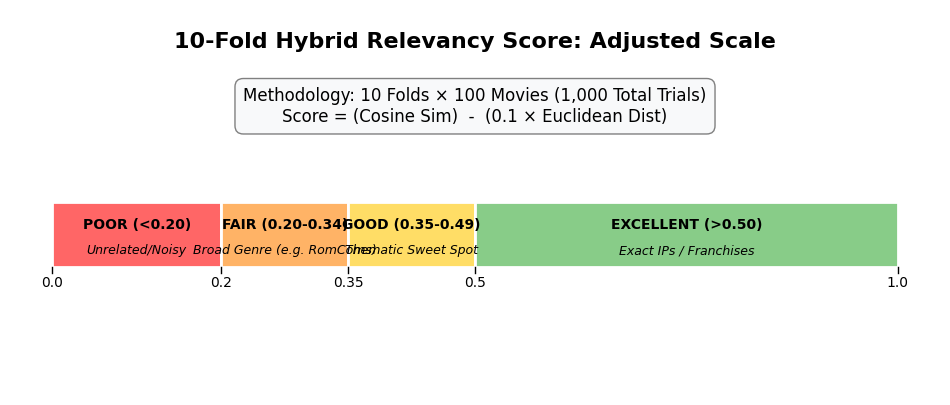

In [32]:
import matplotlib.pyplot as plt

def print_robust_methodology():
    print("\n" + "="*85)
    print("📋 10-FOLD ROBUST EVALUATION METHODOLOGY & LEGEND")
    print("="*85)
    print("WHAT IS THIS SCORE?")
    print("A 'Hybrid Relevancy Score' evaluating unsupervised clustering by balancing semantic")
    print("meaning (Cosine Similarity) with spatial constraints (Euclidean Distance).\n")
    
    print("HOW IS IT CALCULATED? (10-Fold Cross-Validation Style)")
    print("1. We run 10 separate iterations (folds).")
    print("2. In each fold, we randomly sample 100 distinct movies.")
    print("3. For each movie, we find the Top 5 matches restricted to its own cluster.")
    print("4. Score = [Cosine Similarity] - (0.1 * [Euclidean Distance])")
    print("5. We average the 10 folds to get the Grand Final Score (1,000 movies tested).\n")
    
    print("SCORE INTERPRETATION LEGEND (Adjusted for Text Embeddings):")
    print("  🟢 0.50 to 1.00 : EXCELLENT (Franchise Match)")
    print("       Near-perfect matches. Usually sequels, anime, or highly specific IPs.")
    print("  🟡 0.35 to 0.49 : GOOD (Thematic Match - The 'Sweet Spot')")
    print("       Highly related themes and genres. Ideal for discovering new movies.")
    print("  🟠 0.20 to 0.34 : FAIR (Broad Genre Match)")
    print("       Matches the broad genre (e.g., generic Rom-Coms) but plots differ heavily.")
    print("  🔴 Below 0.20   : POOR (Noisy)")
    print("       Unrelated recommendations. Cluster boundaries are too loose.")
    print("="*85 + "\n")

def plot_robust_legend():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_axis_off()
    
    plt.text(0.5, 1.1, "10-Fold Hybrid Relevancy Score: Adjusted Scale", 
             fontsize=16, fontweight='bold', ha='center', va='center')
    
    formula_text = (
        "Methodology: 10 Folds × 100 Movies (1,000 Total Trials)\n"
        "Score = (Cosine Sim)  -  (0.1 × Euclidean Dist)"
    )
    plt.text(0.5, 0.9, formula_text, fontsize=12, ha='center', va='center', 
             bbox=dict(facecolor='#f8f9fa', edgecolor='gray', boxstyle='round,pad=0.5'))
    
    # Updated Segments based on our NLP text reality check
    segments = [
        (0.00, 0.20, '#ff6666', 'POOR (<0.20)', 'Unrelated/Noisy'),
        (0.20, 0.15, '#ffb366', 'FAIR (0.20-0.34)', 'Broad Genre (e.g. RomComs)'),
        (0.35, 0.15, '#ffdd66', 'GOOD (0.35-0.49)', 'Thematic Sweet Spot'),
        (0.50, 0.50, '#88cc88', 'EXCELLENT (>0.50)', 'Exact IPs / Franchises')
    ]
    
    gauge_y = 0.4; gauge_height = 0.2
    
    for start, width, color, title, desc in segments:
        rect = plt.Rectangle((start, gauge_y), width, gauge_height, 
                             facecolor=color, edgecolor='white', linewidth=2)
        ax.add_patch(rect)
        plt.text(start + width/2, gauge_y + gauge_height/2 + 0.03, title, 
                 fontsize=10, fontweight='bold', ha='center', va='center')
        plt.text(start + width/2, gauge_y + gauge_height/2 - 0.05, desc, 
                 fontsize=9, ha='center', va='center', style='italic')

    for val in [0.0, 0.20, 0.35, 0.50, 1.0]:
        plt.text(val, gauge_y - 0.05, str(val), fontsize=10, ha='center', va='center')
        plt.plot([val, val], [gauge_y, gauge_y - 0.02], color='black', lw=1)

    plt.xlim(-0.05, 1.05); plt.ylim(0, 1.2)
    plt.savefig('Robust_Evaluation_Legend.png', dpi=300, bbox_inches='tight')
    plt.show()

print_robust_methodology()
plot_robust_legend()

In [34]:
import numpy as np
import pandas as pd
import joblib
import random
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# ==========================================
# 0. THE CRITICAL FIX
# Reset the index to prevent the IndexError caused by dropped duplicates
# ==========================================
print("Aligning dataframe indices with embedding arrays...")
df.reset_index(drop=True, inplace=True)


# ==========================================
# 1. LOAD THE MODELS
# ==========================================
print("Loading Models...")
kmeans_model = joblib.load('models/kmeans_movie_model.joblib')

# Note: Agglomerative (Hierarchical) clustering usually relies on the labels stored in your dataframe, 
# but if you saved the object, we can load it. We will primarily use the dataframe labels.
try:
    h_model = joblib.load('models/h_cluster_movie_model.joblib')
except FileNotFoundError:
    print("Hierarchical model file not found, relying entirely on dataframe labels.")


# ==========================================
# 2. THE EVALUATION ENGINE
# ==========================================
def run_comprehensive_evaluation(df, embeddings, model_type="kmeans", n_trials=100, top_k=5):
    print(f"\n{'='*70}")
    print(f"🚀 RUNNING 100-MOVIE BATCH EVALUATION FOR: {model_type.upper()}")
    print(f"{'='*70}")
    
    # Define which cluster column to use based on the model we are testing
    cluster_col = 'Cluster' if model_type == 'kmeans' else 'Hierarchical_Cluster'
    
    # Store all trial scores to calculate the final average
    all_scores = []
    sample_logs = [] # To store the 5 examples to print later
    
    # Pick 100 random movies from the dataset
    random_indices = random.sample(range(len(df)), n_trials)
    
    for i, idx in enumerate(random_indices):
        query_title = df.iloc[idx]['Title']
        query_vec = embeddings[idx].reshape(1, -1)
        query_cluster = df.iloc[idx][cluster_col]
        
        # Step A: Filter dataset to only movies in the SAME cluster (The Cluster Constraint)
        cluster_df = df[(df[cluster_col] == query_cluster) & (df.index != idx)]
        
        if cluster_df.empty:
            continue # Skip if it's the only movie in the cluster
            
        cluster_indices = cluster_df.index.tolist()
        cluster_embeddings = embeddings[cluster_indices]
        
        # Step B: Calculate Semantic Similarity (Cosine) and Spatial Distance (Euclidean)
        sim_scores = cosine_similarity(query_vec, cluster_embeddings).flatten()
        dist_scores = euclidean_distances(query_vec, cluster_embeddings).flatten()
        
        # Step C: Get Top 5 based on Similarity
        top_5_relative_indices = sim_scores.argsort()[-top_k:][::-1]
        
        movie_scores = []
        rec_details = []
        
        for rel_idx in top_5_relative_indices:
            real_idx = cluster_indices[rel_idx]
            rec_title = df.iloc[real_idx]['Title']
            
            sim = sim_scores[rel_idx]
            dist = dist_scores[rel_idx]
            
            # CUSTOM METRIC: Similarity minus a small distance penalty
            # We multiply distance by 0.1 so it doesn't overpower the similarity score
            hybrid_score = sim - (0.1 * dist) 
            movie_scores.append(hybrid_score)
            
            rec_details.append(f"{rec_title} (Sim: {sim:.2f}, Dist: {dist:.2f} -> Score: {hybrid_score:.2f})")
            
        # Average score for this specific query movie
        # Handle cases where movie_scores might be empty
        if len(movie_scores) > 0:
            avg_query_score = np.mean(movie_scores)
            all_scores.append(avg_query_score)
        else:
            continue
            
        # Save the first 5 queries to print out as examples
        if len(sample_logs) < 5:
            sample_logs.append({
                "query": query_title,
                "recs": rec_details,
                "avg_score": avg_query_score
            })
            
    # Step D: Calculate Final Average across all 100 movies
    final_system_score = np.mean(all_scores) if all_scores else 0.0
    
    # --- PRINT THE REPORT ---
    print("\n🔍 SAMPLE RESULTS (5 out of 100):")
    for log in sample_logs:
        print(f"\n🎬 Input Movie: '{log['query']}'")
        for j, rec in enumerate(log['recs']):
            print(f"   {j+1}. {rec}")
        print(f"   >>> Average Score for this movie: {log['avg_score']:.3f}")
        
    print(f"\n{'='*70}")
    print(f"🏆 FINAL {model_type.upper()} SYSTEM SCORE: {final_system_score:.4f}")
    print(f"{'='*70}")
    
    return final_system_score


# ==========================================
# 3. RUN THE EVALUATIONS
# ==========================================

print("\nStarting Evaluation Suite...")

kmeans_final_score = run_comprehensive_evaluation(df, embeddings, model_type="kmeans")

hierarchical_final_score = run_comprehensive_evaluation(df, embeddings, model_type="hierarchical")

print("\nEvaluation Complete! Compare the two final system scores to see which model performed better.")

Aligning dataframe indices with embedding arrays...
Loading Models...

Starting Evaluation Suite...

🚀 RUNNING 100-MOVIE BATCH EVALUATION FOR: KMEANS

🔍 SAMPLE RESULTS (5 out of 100):

🎬 Input Movie: 'Unknown Origins'
   1. Spiral: From the Book of Saw (Sim: 0.54, Dist: 0.96 -> Score: 0.44)
   2. The Replacement Killers (Sim: 0.49, Dist: 1.01 -> Score: 0.39)
   3. Basic Instinct (Sim: 0.49, Dist: 1.01 -> Score: 0.39)
   4. The Crow: Salvation (Sim: 0.49, Dist: 1.01 -> Score: 0.38)
   5. R.I.P.D. (Sim: 0.48, Dist: 1.02 -> Score: 0.38)
   >>> Average Score for this movie: 0.398

🎬 Input Movie: 'The Offering'
   1. Dead Silence (Sim: 0.57, Dist: 0.93 -> Score: 0.47)
   2. If Only (Sim: 0.55, Dist: 0.95 -> Score: 0.46)
   3. Practical Magic (Sim: 0.51, Dist: 0.99 -> Score: 0.41)
   4. Hellraiser: Hellseeker (Sim: 0.50, Dist: 1.00 -> Score: 0.40)
   5. Secret Obsession (Sim: 0.49, Dist: 1.01 -> Score: 0.39)
   >>> Average Score for this movie: 0.426

🎬 Input Movie: 'Batman Unlimited: Mechs 

In [39]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# IMPORTANT: Ensure indices are aligned
df.reset_index(drop=True, inplace=True)

def run_10_fold_evaluation(df, embeddings, model_type="kmeans", k_folds=10, samples_per_fold=100, top_k=5):
    print(f"\n{'='*75}")
    print(f"🚀 INITIATING {k_folds}-FOLD VALIDATION FOR: {model_type.upper()}")
    print(f"   Testing {samples_per_fold} movies per fold ({k_folds * samples_per_fold} total)")
    print(f"{'='*75}")
    
    cluster_col = 'Cluster' if model_type == 'kmeans' else 'Hierarchical_Cluster'
    fold_scores = []
    
    # Helper function to label the scores based on our new legend
    def get_score_label(score):
        if score >= 0.50:
            return "EXCELLENT 🟢"
        elif score >= 0.35:
            return "GOOD 🟡"
        elif score >= 0.20:
            return "FAIR 🟠"
        else:
            return "POOR 🔴"
    
    for fold in range(k_folds):
        fold_movie_scores = []
        
        # Pick 100 random movies for THIS specific fold
        random_indices = random.sample(range(len(df)), samples_per_fold)
        
        for idx in random_indices:
            query_vec = embeddings[idx].reshape(1, -1)
            query_cluster = df.iloc[idx][cluster_col]
            
            # Filter to SAME cluster
            cluster_df = df[(df[cluster_col] == query_cluster) & (df.index != idx)]
            if cluster_df.empty:
                continue 
                
            cluster_indices = cluster_df.index.tolist()
            cluster_embeddings = embeddings[cluster_indices]
            
            # Calculate Similarity and Distance
            sim_scores = cosine_similarity(query_vec, cluster_embeddings).flatten()
            dist_scores = euclidean_distances(query_vec, cluster_embeddings).flatten()
            
            # Get Top 5 
            top_5_relative_indices = sim_scores.argsort()[-top_k:][::-1]
            
            movie_recs_scores = []
            for rel_idx in top_5_relative_indices:
                sim = sim_scores[rel_idx]
                dist = dist_scores[rel_idx]
                
                # Formula: Sim - (0.1 * Dist)
                hybrid_score = sim - (0.1 * dist) 
                movie_recs_scores.append(hybrid_score)
                
            if len(movie_recs_scores) > 0:
                fold_movie_scores.append(np.mean(movie_recs_scores))
                
        # Calculate the average for THIS fold
        current_fold_avg = np.mean(fold_movie_scores) if fold_movie_scores else 0.0
        fold_scores.append(current_fold_avg)
        
        # Print progress to the terminal WITH the label
        fold_label = get_score_label(current_fold_avg)
        print(f"   ▶ Fold {fold + 1:02d}/{k_folds} Score: {current_fold_avg:.4f}  |  {fold_label}")

    # Calculate Grand Total Average
    grand_system_score = np.mean(fold_scores)
    grand_label = get_score_label(grand_system_score)
    
    print(f"{'-'*75}")
    print(f"🏆 GRAND FINAL {model_type.upper()} SCORE: {grand_system_score:.4f}  |  Overall: {grand_label}")
    print(f"{'='*75}")
    
    # THE CRITICAL FIX: Returning BOTH variables so we can plot them!
    return grand_system_score, fold_scores

In [40]:
# Run the evaluations and save the lists of all 10 scores
kmeans_grand, kmeans_history = run_10_fold_evaluation(df, embeddings, model_type="kmeans")
hier_grand, hier_history = run_10_fold_evaluation(df, embeddings, model_type="hierarchical")


🚀 INITIATING 10-FOLD VALIDATION FOR: KMEANS
   Testing 100 movies per fold (1000 total)
   ▶ Fold 01/10 Score: 0.3882  |  GOOD 🟡
   ▶ Fold 02/10 Score: 0.3807  |  GOOD 🟡
   ▶ Fold 03/10 Score: 0.3776  |  GOOD 🟡
   ▶ Fold 04/10 Score: 0.3840  |  GOOD 🟡
   ▶ Fold 05/10 Score: 0.3790  |  GOOD 🟡
   ▶ Fold 06/10 Score: 0.3751  |  GOOD 🟡
   ▶ Fold 07/10 Score: 0.3695  |  GOOD 🟡
   ▶ Fold 08/10 Score: 0.3700  |  GOOD 🟡
   ▶ Fold 09/10 Score: 0.3789  |  GOOD 🟡
   ▶ Fold 10/10 Score: 0.3809  |  GOOD 🟡
---------------------------------------------------------------------------
🏆 GRAND FINAL KMEANS SCORE: 0.3784  |  Overall: GOOD 🟡

🚀 INITIATING 10-FOLD VALIDATION FOR: HIERARCHICAL
   Testing 100 movies per fold (1000 total)
   ▶ Fold 01/10 Score: 0.3543  |  GOOD 🟡
   ▶ Fold 02/10 Score: 0.3701  |  GOOD 🟡
   ▶ Fold 03/10 Score: 0.3546  |  GOOD 🟡
   ▶ Fold 04/10 Score: 0.3558  |  GOOD 🟡
   ▶ Fold 05/10 Score: 0.3519  |  GOOD 🟡
   ▶ Fold 06/10 Score: 0.3606  |  GOOD 🟡
   ▶ Fold 07/10 Score: 0.3497

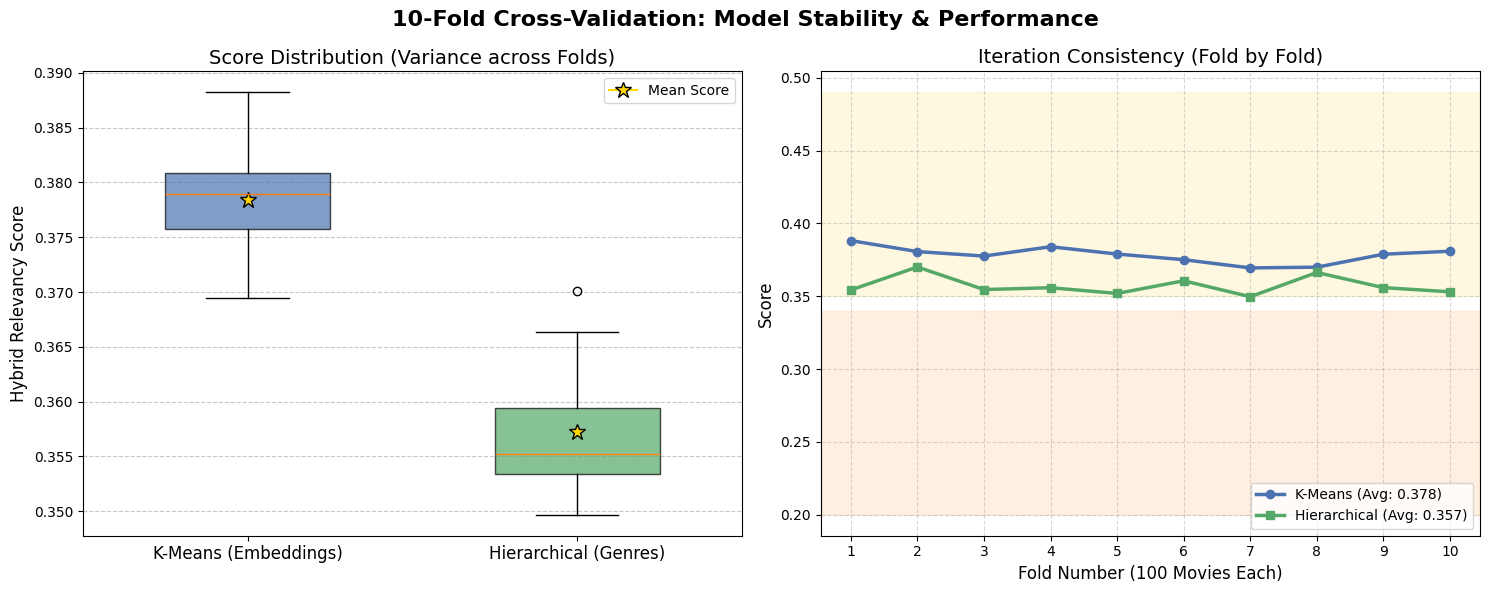

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_performance_plots(kmeans_scores, hier_scores):
    # Set up the figure with 2 side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('10-Fold Cross-Validation: Model Stability & Performance', fontsize=16, fontweight='bold')
    
    # ==========================================
    # PLOT 1: The Box-and-Whisker Plot (Variance)
    # ==========================================
    box_data = [kmeans_scores, hier_scores]
    colors = ['#4C72B0', '#55A868'] # Professional Blue and Green
    
    bplot = ax1.boxplot(box_data, patch_artist=True, widths=0.5)
    
    # Color the boxes
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        
    ax1.set_title('Score Distribution (Variance across Folds)', fontsize=14)
    ax1.set_xticklabels(['K-Means (Embeddings)', 'Hierarchical (Genres)'], fontsize=12)
    ax1.set_ylabel('Hybrid Relevancy Score', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add mean markers
    ax1.plot([1], [np.mean(kmeans_scores)], marker='*', color='gold', markersize=12, markeredgecolor='black', label='Mean Score')
    ax1.plot([2], [np.mean(hier_scores)], marker='*', color='gold', markersize=12, markeredgecolor='black')
    ax1.legend()

    # ==========================================
    # PLOT 2: The Line Graph (Fold Trajectory)
    # ==========================================
    folds = np.arange(1, 11)
    
    ax2.plot(folds, kmeans_scores, marker='o', linewidth=2.5, color='#4C72B0', label=f'K-Means (Avg: {np.mean(kmeans_scores):.3f})')
    ax2.plot(folds, hier_scores, marker='s', linewidth=2.5, color='#55A868', label=f'Hierarchical (Avg: {np.mean(hier_scores):.3f})')
    
    ax2.set_title('Iteration Consistency (Fold by Fold)', fontsize=14)
    ax2.set_xlabel('Fold Number (100 Movies Each)', fontsize=12)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_xticks(folds)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Highlight the Legend Zones on the background
    ax2.axhspan(0.35, 0.49, color='#ffdd66', alpha=0.2, label='Good (Sweet Spot)')
    ax2.axhspan(0.20, 0.34, color='#ffb366', alpha=0.2, label='Fair (Broad Genre)')

    plt.tight_layout()
    plt.savefig('Model_Comparison_Plots.png', dpi=300)
    plt.show()

# Trigger the plot using the history variables we saved!
generate_performance_plots(kmeans_history, hier_history)